# M5 Model Exploration: Random Forest & Ridge Regression

In [2]:
import os, gc, warnings, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)

RANDOM_STATE = 1234
np.random.seed(RANDOM_STATE)

## 1. Load & Inspect Data

In [3]:
# Update DATA_PATH to match your local environment.
DATA_PATH = Path("../results/long_df_with_features.parquet")  # output of notebook 03

df = pd.read_parquet(DATA_PATH)
print(f"Shape: {df.shape}")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Unique series: {df['id'].nunique():,}")
print(f"\nColumn types:")
for col in df.columns:
    print(f"  {col:25s} {str(df[col].dtype):12s} NaN={df[col].isna().sum():>10,}")


Shape: (16098720, 21)
Date range: 2014-12-12 → 2016-05-22
Unique series: 30,490

Column types:
  id                        object       NaN=         0
  item_id                   object       NaN=         0
  dept_id                   object       NaN=         0
  cat_id                    object       NaN=         0
  store_id                  object       NaN=         0
  state_id                  object       NaN=         0
  date                      datetime64[ns] NaN=         0
  demand                    int16        NaN=         0
  is_active                 int8         NaN=         0
  sell_price                float32      NaN=         0
  price_change              float32      NaN=         0
  is_promo                  int8         NaN=         0
  dow                       int8         NaN=         0
  month                     int8         NaN=         0
  lag_7                     float32      NaN=   213,430
  lag_28                    float32      NaN=   853,720
  rmean

## 2. Prepare for Modeling

In [4]:
# =========================
# Filter to active rows & drop NaN
# =========================
df = df[df["is_active"] == 1].reset_index(drop=True)
print(f"After active filter: {df.shape}")

# Required features — drop rows where these are NaN
required_cols = ["lag_7", "lag_28", "rmean_7", "rmean_28", "lag_56", "sell_price"]
df = df.dropna(subset=required_cols).reset_index(drop=True)
print(f"After dropping NaN: {df.shape}")

After active filter: (15974786, 21)
After dropping NaN: (14315186, 21)


In [5]:
# =========================
# Define feature columns
# =========================
categorical_cols = ["item_id", "dept_id", "cat_id", "store_id", "state_id"]

numerical_cols = [
    "sell_price", "price_change", "is_promo",
    "dow", "month",
    "lag_7", "lag_28", "lag_56",
    "rmean_7", "rmean_28",
    "snap_flag", "is_event",
]

target = "demand"
feature_cols = categorical_cols + numerical_cols

print(f"Categorical features: {len(categorical_cols)}")
print(f"Numerical features: {len(numerical_cols)}")
print(f"Total features: {len(feature_cols)}")

Categorical features: 5
Numerical features: 12
Total features: 17


In [6]:
# =========================
# Label-encode categoricals
# =========================
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
    print(f"  {col}: {len(le.classes_)} classes")

  item_id: 3049 classes
  dept_id: 7 classes
  cat_id: 3 classes
  store_id: 10 classes
  state_id: 3 classes


In [7]:
# =========================
# Train / Validation split (last 28 days)
# =========================
VALID_DAYS = 28
max_date = df["date"].max()
valid_start = max_date - pd.Timedelta(days=VALID_DAYS - 1)

train_df = df[df["date"] < valid_start].copy()
valid_df = df[df["date"] >= valid_start].copy()

print(f"Validation window: {valid_start.date()} → {max_date.date()}")
print(f"Train: {train_df.shape}")
print(f"Valid: {valid_df.shape}")

Validation window: 2016-04-25 → 2016-05-22
Train: (13461466, 21)
Valid: (853720, 21)


In [8]:
# =========================
# Sample training data for practical runtime
# =========================
# Random Forest and Ridge on 14M+ rows would take hours.
# We sample strategically: keep ALL validation data but subsample training.

TRAIN_SAMPLE_SIZE = 500_000  # Adjust based on your machine's RAM/patience

if len(train_df) > TRAIN_SAMPLE_SIZE:
    train_sample = train_df.sample(n=TRAIN_SAMPLE_SIZE, random_state=RANDOM_STATE)
    print(f"Sampled training data: {len(train_sample):,} / {len(train_df):,}")
else:
    train_sample = train_df
    print(f"Using full training data: {len(train_sample):,}")

X_train = train_sample[feature_cols].values.astype(np.float32)
y_train = train_sample[target].values.astype(np.float32)
X_valid = valid_df[feature_cols].values.astype(np.float32)
y_valid = valid_df[target].values.astype(np.float32)

# Fill any remaining NaN with 0 (safety net)
X_train = np.nan_to_num(X_train)
X_valid = np.nan_to_num(X_valid)

print(f"\nX_train: {X_train.shape}")
print(f"X_valid: {X_valid.shape}")
print(f"y_train mean: {y_train.mean():.3f}, zero%: {(y_train==0).mean()*100:.1f}%")
print(f"y_valid mean: {y_valid.mean():.3f}, zero%: {(y_valid==0).mean()*100:.1f}%")

Sampled training data: 500,000 / 13,461,466

X_train: (500000, 17)
X_valid: (853720, 17)
y_train mean: 1.284, zero%: 59.8%
y_valid mean: 1.443, zero%: 54.4%


In [9]:
# =========================
# Scale features (needed for Ridge, doesn't hurt RF)
# =========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

# Free memory from the full dataframes
del train_df, train_sample
gc.collect()

print("Features scaled.")

Features scaled.


## 3. Model 1: Random Forest

In [10]:
# =========================
# Train Random Forest
# =========================
print("Training Random Forest...")
t0 = time.time()

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=20,
    max_features="sqrt",
    n_jobs=-1,              # Use all CPU cores
    random_state=RANDOM_STATE,
    verbose=1,
)

# RF doesn't need scaled features, but using them doesn't hurt
rf_model.fit(X_train, y_train)
rf_time = time.time() - t0
print(f"\nTraining time: {rf_time:.1f}s")

Training Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:   13.5s



Training time: 23.4s


[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:   23.2s finished


In [11]:
# =========================
# RF Predictions & Metrics
# =========================
rf_preds = rf_model.predict(X_valid).clip(min=0)

rf_rmse = np.sqrt(mean_squared_error(y_valid, rf_preds))
rf_mae = mean_absolute_error(y_valid, rf_preds)

print(f"Random Forest Results:")
print(f"  RMSE: {rf_rmse:.4f}")
print(f"  MAE:  {rf_mae:.4f}")
print(f"  Mean prediction: {rf_preds.mean():.3f}")
print(f"  Predictions < 0 (before clip): n/a (clipped)")

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.2s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    1.7s


Random Forest Results:
  RMSE: 2.0802
  MAE:  1.0320
  Mean prediction: 1.403
  Predictions < 0 (before clip): n/a (clipped)


[Parallel(n_jobs=16)]: Done 300 out of 300 | elapsed:    2.9s finished


Random Forest — Feature Importance:


,feature,importance
13,rmean_7,2.888836e-01
14,rmean_28,2.510356e-01
10,lag_7,2.058077e-01
11,lag_28,1.168163e-01
12,lag_56,7.360313e-02
5,sell_price,2.029068e-02
0,item_id,1.320528e-02
8,dow,8.954521e-03
9,month,4.894334e-03
3,store_id,4.501063e-03


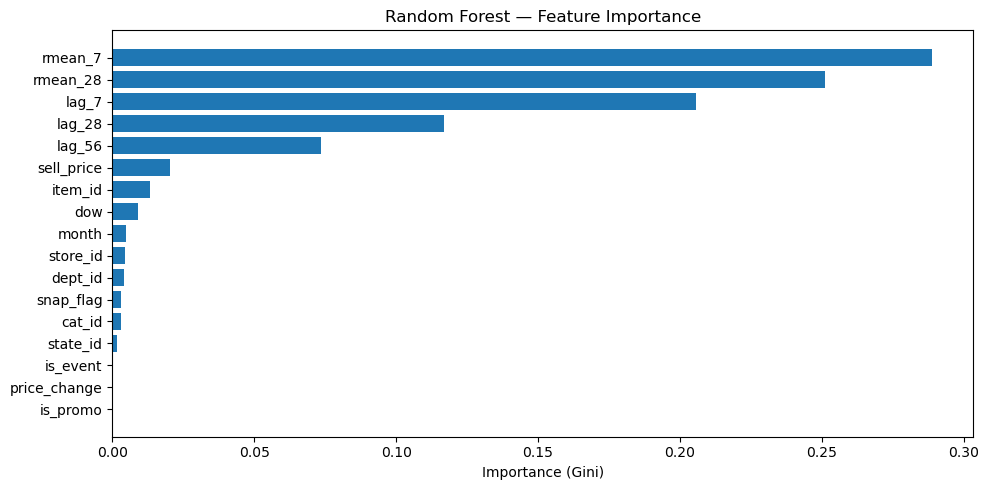

In [12]:
# =========================
# RF Feature Importance
# =========================
rf_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

print("Random Forest — Feature Importance:")
display(rf_importance)

plt.figure(figsize=(10, 5))
plt.barh(rf_importance["feature"][::-1], rf_importance["importance"][::-1])
plt.title("Random Forest — Feature Importance")
plt.xlabel("Importance (Gini)")
plt.tight_layout()
plt.show()

## 4. Model 2: Ridge Regression

In [13]:
# =========================
# Train Ridge Regression
# =========================
print("Training Ridge Regression...")
t0 = time.time()

ridge_model = Ridge(
    alpha=0.5,              # Regularization strength (higher = more conservative)
    fit_intercept=True,
    random_state=RANDOM_STATE,
)

# Ridge NEEDS scaled features
ridge_model.fit(X_train_scaled, y_train)
ridge_time = time.time() - t0
print(f"Training time: {ridge_time:.1f}s")

Training Ridge Regression...
Training time: 0.1s


In [14]:
# =========================
# Ridge Predictions & Metrics
# =========================
ridge_preds_raw = ridge_model.predict(X_valid_scaled)
n_negative = (ridge_preds_raw < 0).sum()
ridge_preds = ridge_preds_raw.clip(min=0)

ridge_rmse = np.sqrt(mean_squared_error(y_valid, ridge_preds))
ridge_mae = mean_absolute_error(y_valid, ridge_preds)

print(f"Ridge Regression Results:")
print(f"  RMSE: {ridge_rmse:.4f}")
print(f"  MAE:  {ridge_mae:.4f}")
print(f"  Mean prediction: {ridge_preds.mean():.3f}")
print(f"  Negative predictions (clipped to 0): {n_negative:,} ({n_negative/len(ridge_preds)*100:.1f}%)")

Ridge Regression Results:
  RMSE: 2.1180
  MAE:  1.0510
  Mean prediction: 1.414
  Negative predictions (clipped to 0): 29,350 (3.4%)


Ridge Regression — Coefficients (scaled features, so magnitudes are comparable):


,feature,coefficient
13,rmean_7,1.450569
10,lag_7,0.562845
11,lag_28,0.421469
14,rmean_28,0.385988
12,lag_56,0.252063
8,dow,0.088016
15,snap_flag,0.077055
2,cat_id,-0.024924
16,is_event,-0.024826
9,month,-0.024723


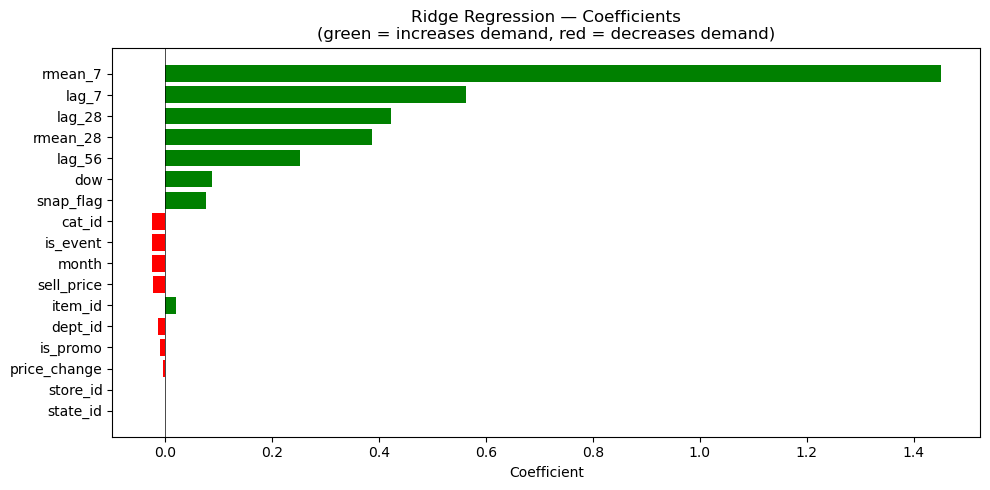

In [15]:
# =========================
# Ridge Coefficients
# =========================
ridge_coefs = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": ridge_model.coef_,
}).sort_values("coefficient", key=abs, ascending=False)

print("Ridge Regression — Coefficients (scaled features, so magnitudes are comparable):")
display(ridge_coefs)

plt.figure(figsize=(10, 5))
colors = ["green" if c > 0 else "red" for c in ridge_coefs["coefficient"]]
plt.barh(ridge_coefs["feature"][::-1], ridge_coefs["coefficient"][::-1], color=colors[::-1])
plt.axvline(0, color="black", linewidth=0.5)
plt.title("Ridge Regression — Coefficients\n(green = increases demand, red = decreases demand)")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()

## 5. Head-to-Head Comparison

In [16]:
# =========================
# Summary table
# =========================
comparison = pd.DataFrame({
    "Model": ["Random Forest", "Ridge Regression"],
    "RMSE": [rf_rmse, ridge_rmse],
    "MAE": [rf_mae, ridge_mae],
    "Mean Prediction": [rf_preds.mean(), ridge_preds.mean()],
    "Training Time (s)": [rf_time, ridge_time],
})

print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
display(comparison.round(4))

MODEL COMPARISON


,Model,RMSE,MAE,Mean Prediction,Training Time (s)
0,Random Forest,2.0802,1.032,1.4030,23.4180
1,Ridge Regression,2.1180,1.051,1.4136,0.1332


In [ ]:
# =========================
# Aggregate actual vs predicted by date
# =========================
valid_df_plot = valid_df[["date", "demand"]].copy()
valid_df_plot["RF_pred"] = rf_preds
valid_df_plot["Ridge_pred"] = ridge_preds

daily = valid_df_plot.groupby("date").sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily["date"], daily["demand"], label="Actual", color="black", linewidth=2)
ax.plot(daily["date"], daily["RF_pred"], label=f"Random Forest (RMSE={rf_rmse:.3f})", linestyle="--")
ax.plot(daily["date"], daily["Ridge_pred"], label=f"Ridge (RMSE={ridge_rmse:.3f})", linestyle="--")
ax.set_title("Validation Period: Actual vs Predicted Daily Total Sales")
ax.set_xlabel("Date")
ax.set_ylabel("Total Units Sold")
ax.legend()
plt.tight_layout()
plt.show()

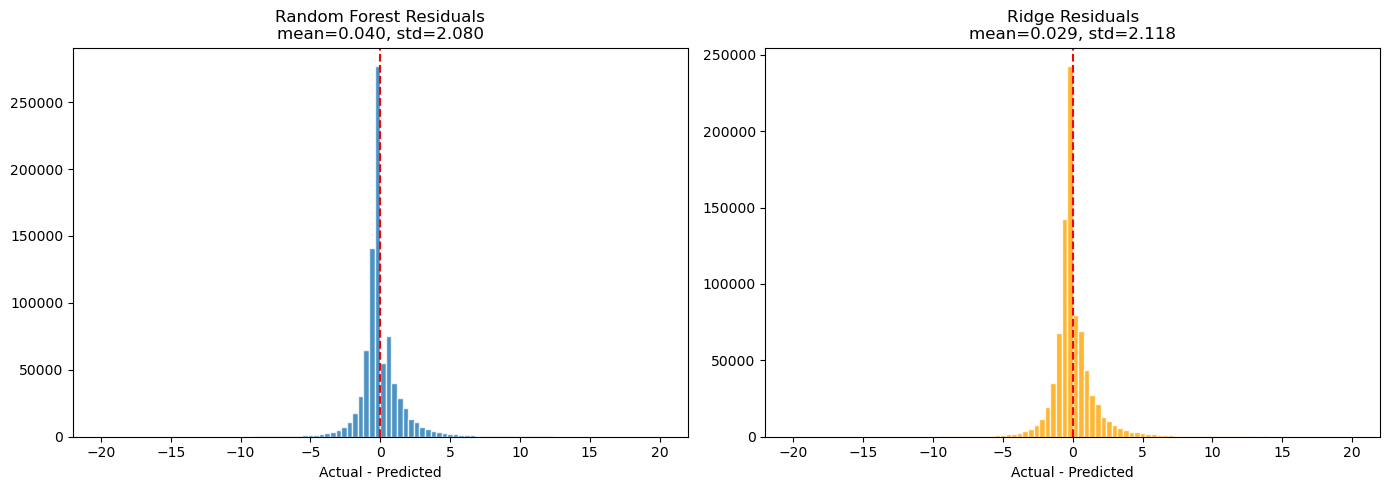

In [17]:
# =========================
# Residual analysis
# =========================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RF residuals
rf_residuals = y_valid - rf_preds
axes[0].hist(rf_residuals, bins=100, edgecolor="white", alpha=0.8, range=(-20, 20))
axes[0].axvline(0, color="red", linestyle="--")
axes[0].set_title(f"Random Forest Residuals\nmean={rf_residuals.mean():.3f}, std={rf_residuals.std():.3f}")
axes[0].set_xlabel("Actual - Predicted")

# Ridge residuals
ridge_residuals = y_valid - ridge_preds
axes[1].hist(ridge_residuals, bins=100, edgecolor="white", alpha=0.8, range=(-20, 20), color="orange")
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_title(f"Ridge Residuals\nmean={ridge_residuals.mean():.3f}, std={ridge_residuals.std():.3f}")
axes[1].set_xlabel("Actual - Predicted")

plt.tight_layout()
plt.show()

Mean Absolute Error by Category:


,rf_error,ridge_error
category,,
FOODS,1.3323,1.3555
HOBBIES,0.7481,0.7725
HOUSEHOLD,0.7732,0.7834


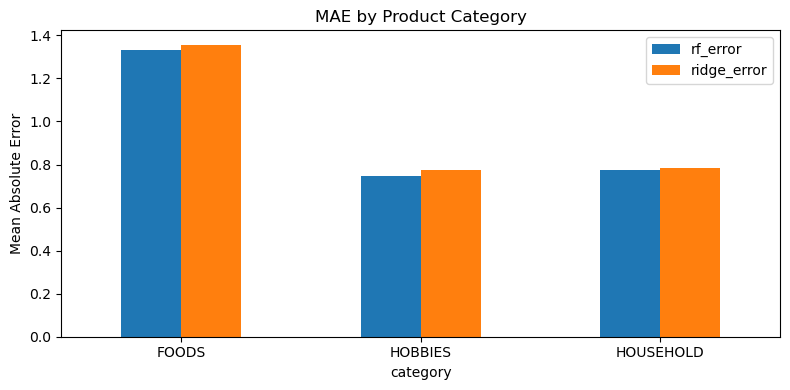

In [18]:
# =========================
# Error by category
# =========================
valid_df_err = valid_df[["id", "cat_id", "store_id"]].copy()
valid_df_err["rf_error"] = np.abs(rf_residuals)
valid_df_err["ridge_error"] = np.abs(ridge_residuals)

# Map cat_id back to names
cat_le = label_encoders["cat_id"]
valid_df_err["category"] = cat_le.inverse_transform(valid_df_err["cat_id"])

cat_errors = valid_df_err.groupby("category")[["rf_error", "ridge_error"]].mean()

print("Mean Absolute Error by Category:")
display(cat_errors.round(4))

cat_errors.plot(kind="bar", figsize=(8, 4), title="MAE by Product Category")
plt.ylabel("Mean Absolute Error")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. WRMSSE Proxy

The official M5 competition metric is WRMSSE (Weighted Root Mean Squared Scaled Error).  
This is a simplified item-store level proxy — not the full hierarchical evaluator, but consistent enough to compare models.

In [20]:
# =========================
# WRMSSE item-store proxy
# =========================
# Reload train data for scale computation
train_for_scale = df[df["date"] < valid_start][["id", "date", "demand", "sell_price"]].copy()

def compute_wrmsse_proxy(train_data, valid_data, preds, pred_name="pred"):
    """Simplified WRMSSE at the item-store level."""

    # 1. Scale: mean squared diff of training demand per series
    scales = []
    for sid, g in train_data.groupby("id", sort=False):
        y = g.sort_values("date")["demand"].values
        nz = np.flatnonzero(y)
        if len(nz) <= 1:
            scales.append((sid, np.nan))
        else:
            y_trim = y[nz[0]:]
            diff = np.diff(y_trim)
            scales.append((sid, np.mean(diff**2) if len(diff) > 0 else np.nan))
    scale_df = pd.DataFrame(scales, columns=["id", "scale"])

    # 2. Weights: dollar sales in last 28 training days
    last_date = train_data["date"].max()
    w_start = last_date - pd.Timedelta(days=27)
    wt = (
        train_data[train_data["date"] >= w_start]
        .assign(dollars=lambda x: x["demand"] * x["sell_price"])
        .groupby("id")["dollars"].sum()
        .reset_index()
    )
    total = wt["dollars"].sum()
    wt["weight"] = wt["dollars"] / total if total > 0 else 1 / len(wt)

    # 3. Series-level RMSE
    eval_df = valid_data[["id"]].copy()
    eval_df["actual"] = valid_data["demand"].values
    eval_df["pred"] = preds
    series_rmse = (
        eval_df.groupby("id")
        .apply(lambda g: np.sqrt(np.mean((g["actual"].values - g["pred"].values)**2)))
        .reset_index(name="rmse")
    )

    # 4. Combine
    merged = series_rmse.merge(scale_df, on="id").merge(wt[["id", "weight"]], on="id")
    merged["rmsse"] = merged["rmse"] / np.sqrt(merged["scale"])
    merged = merged.replace([np.inf, -np.inf], np.nan).dropna(subset=["rmsse", "weight"])
    merged["weight"] = merged["weight"] / merged["weight"].sum()

    return (merged["weight"] * merged["rmsse"]).sum()

rf_wrmsse = compute_wrmsse_proxy(train_for_scale, valid_df, rf_preds)
ridge_wrmsse = compute_wrmsse_proxy(train_for_scale, valid_df, ridge_preds)

print(f"WRMSSE Proxy:")
print(f"  Random Forest:    {rf_wrmsse:.6f}")
print(f"  Ridge Regression: {ridge_wrmsse:.6f}")

del train_for_scale; gc.collect()

WRMSSE Proxy:
  Random Forest:    0.801888
  Ridge Regression: 0.820155


0

## 7. Final Summary & Recommendations

In [21]:
# =========================
# Final summary
# =========================
final = pd.DataFrame({
    "Model": ["Random Forest", "Ridge Regression"],
    "RMSE": [rf_rmse, ridge_rmse],
    "MAE": [rf_mae, ridge_mae],
    "WRMSSE Proxy": [rf_wrmsse, ridge_wrmsse],
    "Training Time (s)": [rf_time, ridge_time],
})

print("=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)
display(final.round(4))

best_model = final.loc[final["RMSE"].idxmin(), "Model"]
print(f"\nBest model by RMSE: {best_model}")

FINAL MODEL COMPARISON


,Model,RMSE,MAE,WRMSSE Proxy,Training Time (s)
0,Random Forest,2.0802,1.032,0.8019,23.4180
1,Ridge Regression,2.1180,1.051,0.8202,0.1332



Best model by RMSE: Random Forest


In [ ]:
# =========================
# Save predictions for ensemble use
# =========================
OUTPUT_DIR = Path("")
OUTPUT_DIR.mkdir(exist_ok=True)

preds_df = valid_df[["id", "date"]].copy()
preds_df["actual"] = y_valid
preds_df["rf_pred"] = rf_preds
preds_df["ridge_pred"] = ridge_preds

preds_df.to_csv(OUTPUT_DIR / "model_exploration_predictions.csv", index=False)
final.to_csv(OUTPUT_DIR / "model_exploration_metrics.csv", index=False)

print(f"Saved predictions: {OUTPUT_DIR / 'model_exploration_predictions.csv'}")
print(f"Saved metrics: {OUTPUT_DIR / 'model_exploration_metrics.csv'}")

## 8. Generate Kaggle Submission Files

### 8a. Configuration

In [ ]:
# =========================
# Submission configuration
# =========================
# Update RAW_DATA_DIR to point to your local copy of the Kaggle M5 data.
RAW_DATA_DIR = Path("../data/raw")

CALENDAR_PATH = RAW_DATA_DIR / "calendar.csv"
PRICES_PATH   = RAW_DATA_DIR / "sell_prices.csv"
SALES_PATH    = RAW_DATA_DIR / "sales_train_evaluation.csv"
SAMPLE_SUB    = RAW_DATA_DIR / "sample_submission.csv"

HORIZON = 28

SUBMISSION_DIR = Path("./submissions")
SUBMISSION_DIR.mkdir(exist_ok=True)


### 8b. Load Raw Data & Build Lookups

In [ ]:
# =========================
# Load raw sales as a numpy matrix
# =========================
sales_raw = pd.read_csv(SALES_PATH)
sub_id_cols = ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]
sub_id_info = sales_raw[sub_id_cols].copy()
n_items = len(sub_id_info)

raw_d_cols = sorted([c for c in sales_raw.columns if c.startswith("d_")],
                    key=lambda x: int(x.split("_")[1]))
sales_matrix = sales_raw[raw_d_cols].values.astype(np.float32)
n_days = sales_matrix.shape[1]  # 1941

del sales_raw; gc.collect()
print(f"Sales matrix: {n_items:,} items × {n_days} days")

In [ ]:
# =========================
# Calendar lookup arrays
# =========================
sub_calendar = pd.read_csv(CALENDAR_PATH)
sub_calendar["d_num"] = sub_calendar["d"].str.extract(r"(\d+)").astype(int)
sub_calendar["has_event"] = sub_calendar["event_name_1"].notna().astype(np.int8)

sub_max_d = sub_calendar["d_num"].max()

sub_cal_wday   = np.zeros(sub_max_d + 1, dtype=np.int8)
sub_cal_month  = np.zeros(sub_max_d + 1, dtype=np.int8)
sub_cal_snap   = np.zeros((sub_max_d + 1, 3), dtype=np.int8)
sub_cal_event  = np.zeros(sub_max_d + 1, dtype=np.int8)
sub_cal_wmyrwk = np.zeros(sub_max_d + 1, dtype=np.int32)

da = sub_calendar["d_num"].values
sub_cal_wday[da]    = sub_calendar["wday"].values.astype(np.int8)
sub_cal_month[da]   = sub_calendar["month"].values.astype(np.int8)
sub_cal_snap[da, 0] = sub_calendar["snap_CA"].values.astype(np.int8)
sub_cal_snap[da, 1] = sub_calendar["snap_TX"].values.astype(np.int8)
sub_cal_snap[da, 2] = sub_calendar["snap_WI"].values.astype(np.int8)
sub_cal_event[da]   = sub_calendar["has_event"].values
sub_cal_wmyrwk[da]  = sub_calendar["wm_yr_wk"].values.astype(np.int32)

del sub_calendar; gc.collect()
print(f"Calendar arrays: d_1 to d_{sub_max_d}")

In [ ]:
# =========================
# Encode categoricals (same encoding as the models were trained on)
# =========================
sub_cat_cols = ["item_id", "dept_id", "cat_id", "store_id", "state_id"]
sub_cat_encoded = {}
for col in sub_cat_cols:
    le = label_encoders[col]  # Reuse the encoders from Section 2
    sub_cat_encoded[col] = le.transform(sub_id_info[col].astype(str)).astype(np.int16)

sub_state_idx = sub_id_info["state_id"].map({"CA": 0, "TX": 1, "WI": 2}).values.astype(np.int8)
print("Categoricals encoded using existing label encoders.")

In [ ]:
# =========================
# Price lookup: per-week price vectors
# =========================
sub_prices = pd.read_csv(PRICES_PATH)
sub_prices["_key"] = sub_prices["store_id"] + "_" + sub_prices["item_id"]
item_store_key = (sub_id_info["store_id"] + "_" + sub_id_info["item_id"]).values
key_to_idx = {k: i for i, k in enumerate(item_store_key)}

sub_prices["_idx"] = sub_prices["_key"].map(key_to_idx)
sub_prices = sub_prices.dropna(subset=["_idx"])
sub_prices["_idx"] = sub_prices["_idx"].astype(np.int32)

sub_wk_prices = {}
for wk, grp in sub_prices.groupby("wm_yr_wk"):
    vec = np.zeros(n_items, dtype=np.float32)
    vec[grp["_idx"].values] = grp["sell_price"].values.astype(np.float32)
    sub_wk_prices[int(wk)] = vec

del sub_prices; gc.collect()
print(f"Price vectors: {len(sub_wk_prices)} weeks")

### 8c. Feature Builder & Recursive Prediction

The feature builder constructs the same 17 features the models were trained on, but from the raw sales matrix instead of the parquet file. The recursive loop predicts one day at a time and feeds each prediction back into the history so future lag features can use it.

In [ ]:
# =========================
# Feature builder for submission predictions
# =========================
N_SUB_FEAT = len(feature_cols)  # Same 17 features as training

def build_submission_features(d, data_matrix):
    """Build features for all items on day d, matching the training feature order."""
    X = np.zeros((n_items, N_SUB_FEAT), dtype=np.float32)
    ncols = data_matrix.shape[1]
    c = 0

    # Categoricals (5) — same order as feature_cols
    for col_name in sub_cat_cols:
        X[:, c] = sub_cat_encoded[col_name]; c += 1

    # sell_price
    wk = int(sub_cal_wmyrwk[min(d, sub_max_d)])
    pvec = sub_wk_prices.get(wk, np.zeros(n_items, dtype=np.float32))
    X[:, c] = pvec; c += 1

    # price_change (simplified: 0 for submission)
    c += 1

    # is_promo (simplified: 0 for submission)
    c += 1

    # dow, month
    X[:, c] = sub_cal_wday[d]; c += 1
    X[:, c] = sub_cal_month[d]; c += 1

    # lag_7, lag_28, lag_56
    for lag in [7, 28, 56]:
        idx = d - lag - 1  # 0-indexed
        if 0 <= idx < ncols:
            X[:, c] = data_matrix[:, idx]
        c += 1

    # rmean_7
    base = d - 7 - 1
    if base >= 6:
        X[:, c] = data_matrix[:, base-6:base+1].mean(axis=1)
    c += 1

    # rmean_28
    base28 = d - 28 - 1
    if base28 >= 27:
        X[:, c] = data_matrix[:, base28-27:base28+1].mean(axis=1)
    c += 1

    # snap_flag, is_event
    X[:, c] = sub_cal_snap[d, sub_state_idx]; c += 1
    X[:, c] = sub_cal_event[d]; c += 1

    return X

print(f"Feature builder ready: {N_SUB_FEAT} features, matching training order:")
print(f"  {feature_cols}")

In [ ]:
# =========================
# Recursive 28-day prediction
# =========================
def predict_horizon(start_day, history_end_day):
    """
    Predict 28 days starting from start_day using history up to history_end_day.
    Returns: rf_preds (n_items, 28), ridge_preds (n_items, 28)
    """
    # Extend the sales matrix with space for predictions
    known = sales_matrix[:, :history_end_day].copy()
    extended = np.concatenate([
        known,
        np.zeros((n_items, HORIZON), dtype=np.float32)
    ], axis=1)

    rf_results = np.zeros((n_items, HORIZON), dtype=np.float32)
    ridge_results = np.zeros((n_items, HORIZON), dtype=np.float32)

    for h in range(HORIZON):
        d = start_day + h

        X = np.nan_to_num(build_submission_features(d, extended))

        # RF prediction
        rf_pred = rf_model.predict(X).clip(min=0).astype(np.float32)

        # Ridge prediction (needs scaling)
        X_sc = scaler.transform(X)
        ridge_pred = ridge_model.predict(X_sc).clip(min=0).astype(np.float32)

        rf_results[:, h] = rf_pred
        ridge_results[:, h] = ridge_pred

        # Feed RF predictions back for recursive lag features
        extended[:, history_end_day + h] = rf_pred

        if (h + 1) % 7 == 0:
            print(f"    F{h+1}/28")

    return rf_results, ridge_results

### 8d. Generate Predictions

In [ ]:
# =========================
# Validation predictions (d_1914 – d_1941)
# =========================
print("Predicting validation period (d_1914 – d_1941)...")
print("  Using history up to d_1913")
val_rf, val_ridge = predict_horizon(start_day=1914, history_end_day=1913)
print("Done.")

In [ ]:
# =========================
# Evaluation predictions (d_1942 – d_1969)
# =========================
print("Predicting evaluation period (d_1942 – d_1969)...")
print("  Using history up to d_1941")
eval_rf, eval_ridge = predict_horizon(start_day=1942, history_end_day=1941)
print("Done.")

### 8e. Format & Save Submissions

In [ ]:
# =========================
# Build submission DataFrames
# =========================
sample_sub = pd.read_csv(SAMPLE_SUB)
f_cols = [f"F{i}" for i in range(1, 29)]

def make_submission(val_preds, eval_preds):
    val_ids = sub_id_info["id"].str.replace("_evaluation", "_validation").values
    eval_ids = sub_id_info["id"].values

    val_df = pd.DataFrame(np.round(val_preds, 4), columns=f_cols)
    val_df.insert(0, "id", val_ids)

    eval_df = pd.DataFrame(np.round(eval_preds, 4), columns=f_cols)
    eval_df.insert(0, "id", eval_ids)

    sub = pd.concat([val_df, eval_df], ignore_index=True)

    # Verify format
    assert sub.shape == sample_sub.shape, f"Shape mismatch: {sub.shape} vs {sample_sub.shape}"
    assert set(sub["id"]) == set(sample_sub["id"]), "ID mismatch!"
    return sub

rf_submission = make_submission(val_rf, eval_rf)
ridge_submission = make_submission(val_ridge, eval_ridge)

print("Both submissions built and verified.")

In [ ]:
# =========================
# Save & sanity check
# =========================
rf_path = SUBMISSION_DIR / "submission_random_forest.csv"
ridge_path = SUBMISSION_DIR / "submission_ridge.csv"

rf_submission.to_csv(rf_path, index=False)
ridge_submission.to_csv(ridge_path, index=False)

for name, sub, path in [("Random Forest", rf_submission, rf_path),
                         ("Ridge", ridge_submission, ridge_path)]:
    vals = sub[f_cols].values
    print(f"\n{name}:")
    print(f"  File: {path}")
    print(f"  Shape: {sub.shape}")
    print(f"  Mean prediction: {vals.mean():.4f}")
    print(f"  Max prediction: {vals.max():.2f}")
    print(f"  Any NaN: {np.isnan(vals).any()}")
    print(f"  Any negative: {(vals < 0).any()}")
    print(f"  First row: {sub.iloc[0, :5].to_dict()}")

print("\n✓ Upload these files to Kaggle:")
print(f"  1. {rf_path}")
print(f"  2. {ridge_path}")